# Neuroevolution on EvoGym

## Getting started

Check that the following line can run. If so, you have evogym installed! Otherwise, you need to install it.

In [85]:
from evogym import sample_robot
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
import matplotlib.pyplot as plt
from matplotlib import animation
import gymnasium as gym
import evogym.envs
from evogym import sample_robot
from evogym.utils import get_full_connectivity
from tqdm import tqdm

## Agent

In [86]:
class Network(nn.Module):
    def __init__(self, n_in, h_size, n_out):
        super().__init__()
        self.fc1 = nn.Linear(n_in, h_size)
        self.fc2 = nn.Linear(h_size, h_size)
        self.fc3 = nn.Linear(h_size, n_out)

        self.n_out = n_out

    def reset(self):
        pass

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)

        x = self.fc2(x)
        x = F.relu(x)

        x = self.fc3(x)
        return x

In [87]:
class Agent:
    def __init__(self, Net, config, genes = None):
        self.config = config
        self.Net = Net
        self.model = None
        self.fitness = None

        self.device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu")

        self.make_network()
        if genes is not None:
            self.genes = genes

    def __repr__(self):  # pragma: no cover
        return f"Agent {self.model} > fitness={self.fitness}"

    def __str__(self):  # pragma: no cover
        return self.__repr__()

    def make_network(self):
        n_in = self.config["n_in"]
        h_size = self.config["h_size"]
        n_out = self.config["n_out"]
        self.model = self.Net(n_in, h_size, n_out).to(self.device).double()
        return self

    @property
    def genes(self):
        if self.model is None:
            return None
        with torch.no_grad():
            params = self.model.parameters()
            vec = torch.nn.utils.parameters_to_vector(params)
        return vec.cpu().double().numpy()

    @genes.setter
    def genes(self, params):
        if self.model is None:
            self.make_network()
        assert len(params) == len(
            self.genes), "Genome size does not fit the network size"
        if np.isnan(params).any():
            raise
        a = torch.tensor(params, device=self.device)
        torch.nn.utils.vector_to_parameters(a, self.model.parameters())
        self.model = self.model.to(self.device).double()
        self.fitness = None
        return self

    def mutate_ga(self):
        genes = self.genes
        n = len(genes)
        f = np.random.choice([False, True], size=n, p=[1/n, 1-1/n])

        new_genes = np.empty(n)
        new_genes[f] = genes[f]
        noise = np.random.randn(n-sum(f))
        new_genes[~f] = noise
        return new_genes

    def act(self, obs):
        # continuous actions
        with torch.no_grad():
            x = torch.tensor(obs).double().unsqueeze(0).to(self.device)
            actions = self.model(x).cpu().detach().numpy()
        return actions


## Environment

In [88]:
walker = np.array([
    [3, 3, 3, 3, 3],
    [3, 3, 3, 3, 3],
    [4, 4, 0, 4, 4],
    [4, 4, 0, 4, 4],
    [4, 4, 0, 4, 4]
    ])

In [89]:
def make_env(env_name, seed=None, robot=None, **kwargs):
    if robot is None:
        env = gym.make(env_name)
    else:
        connections = get_full_connectivity(robot)
        env = gym.make(env_name, body=robot)
    env.robot = robot
    if seed is not None:
        env.seed(seed)

    return env

In [90]:
def evaluate(agent, env, max_steps=500, render=False):
    obs, i = env.reset()
    agent.model.reset()
    reward = 0
    steps = 0
    done = False
    while not done and steps < max_steps:
        if render:
            env.render()
        action = agent.act(obs)
        obs, r, done, trunc, _ = env.step(action)
        reward += r
        steps += 1
    return reward

In [91]:
def get_cfg(env_name, robot=None):
    env = make_env(env_name, robot=walker)
    cfg = {
        "n_in": env.observation_space.shape[0],
        "h_size": 32,
        "n_out": env.action_space.shape[0],
    }
    env.close()
    return cfg

In [92]:
env_name = 'Thrower-v0'
robot = walker

cfg = get_cfg(env_name, robot)
a = Agent(Network, cfg)
a

Agent Network(
  (fc1): Linear(in_features=78, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=22, bias=True)
) > fitness=None

In [93]:
env = make_env(env_name, robot=walker)
s = env.reset()
len(s), s

(2,
 (array([ 0.  ,  0.  ,  0.1 ,  0.45,  0.  ,  0.  , -0.25, -0.15, -0.25,
         -0.15, -0.05, -0.05,  0.05,  0.05,  0.15,  0.15,  0.25,  0.25,
         -0.25, -0.15, -0.05,  0.05,  0.15,  0.25, -0.25, -0.15, -0.05,
          0.05,  0.15,  0.25, -0.25, -0.15, -0.05,  0.05,  0.15,  0.25,
         -0.25, -0.15, -0.05,  0.05,  0.15,  0.25,  0.25,  0.25,  0.15,
          0.15,  0.25,  0.15,  0.25,  0.15,  0.25,  0.15,  0.25,  0.15,
          0.05,  0.05,  0.05,  0.05,  0.05,  0.05, -0.05, -0.05, -0.05,
         -0.05, -0.05, -0.05, -0.15, -0.15, -0.15, -0.15, -0.15, -0.15,
         -0.25, -0.25, -0.25, -0.25, -0.25, -0.25]),
  {}))

In [94]:
# Evaluation
env = make_env(env_name, robot=walker)
reward = evaluate(a, env, render=True)
print(f"Reward: {reward}")
env.close()

Reward: 0.42402271548729337


In [95]:
def mp_eval(a, cfg):
    env = make_env(cfg["env_name"], robot=cfg["robot"])
    fit = evaluate(a, env, max_steps=cfg["max_steps"])
    env.close()
    return fit

## Algorithms trial


In [96]:
# seeds_1 = {'env_seed':1945382, 'random_seed':83248}
# seeds_2 = {'env_seed':3642, 'random_seed':4512783}

In [97]:
# def RUN(env_name, robot, params, Net, algo, seeds):
#     my_elites = []
#     for param in params:
#         config = {
#             "env_name": env_name,
#             "robot": robot,
#             "generations": param[0], # to change: increase!
#             "lambda": param[1], # Population size
#             "mu": param[2], # Parents pop size
#             "sigma": param[3], # mutation std
#             "lr": param[4], # Learning rate
#             "max_steps": param[5], # to change to 500
#         }
#         a, plot_info = algo(config, Net, **seeds)
#         print(a.fitness)
#         my_elites.append((a, config, plot_info))
#     return my_elites

In [98]:
# params_500 = [
#     [125, 4, None, None, None, 100],
#     [100, 5, None, None, None, 100],
#     [50, 10, None, None, None, 100],
#     [25, 20, None, None, None, 100]
# ]

# params_1000 = [
#     [250, 4, None, None, None, 100],
#     [200, 5, None, None, None, 100],
#     [125, 8, None, None, None, 100],
#     [100, 10, None, None, None, 100],
#     [50, 20, None, None, None, 100],
#     [40, 25, None, None, None, 100]
# ]

# params_5000 = [
#     [1250, 4, None, None, None, 100],
#     [1000, 5, None, None, None, 100],
#     [625, 8, None, None, None, 100],
#     [500, 10, None, None, None, 100],
#     [250, 20, None, None, None, 100],
#     [200, 25, None, None, None, 100],
#     [125, 40, None, None, None, 100],
#     [100, 50, None, None, None, 100]
# ]

# params_10000 = [
#     [2500, 4, None, None, None, 100],
#     [2000, 5, None, None, None, 100],
#     [1250, 8, None, None, None, 100],
#     [1000, 10, None, None, None, 100],
#     [625, 16, None, None, None, 100],
#     [500, 20, None, None, None, 100],
#     [400, 25, None, None, None, 100],
#     [250, 40, None, None, None, 100],
#     [200, 50, None, None, None, 100],
#     [125, 80, None, None, None, 100],
#     [100, 100, None, None, None, 100]
# ]

## Algorithms
### 1+$\lambda$ EA

In [99]:
# def one_plus_lambda(config):
#     cfg = get_cfg(config["env_name"], robot=config["robot"]) # Get network dims
#     cfg = {**config, **cfg} # Merge configs

#     env = make_env(cfg["env_name"], robot=cfg["robot"])

#     # Elite
#     elite = Agent(Network, cfg)

#     elite.fitness = evaluate(elite, env, max_steps=cfg["max_steps"])

#     fits = []
#     total_evals = []

#     bar = tqdm(range(cfg["generations"]))
#     for gen in bar:
#         population = [Agent(Network, cfg, genes=elite.mutate_ga())
#             for _ in range(cfg["lambda"])]

#         # with Pool(processes=len(population)) as pool:
#             # pop_fitness = pool.starmap(mp_eval, [(a, cfg) for a in population])

#         pop_fitness = [evaluate(a, env, max_steps=cfg["max_steps"]) for a in population]

#         best = np.argmax(pop_fitness)
#         best_fit = pop_fitness[best]
#         if best_fit > elite.fitness:
#             elite.genes = population[best].genes
#             elite.fitness = best_fit
#         fits.append(elite.fitness)
#         total_evals.append(len(population) * (gen+1))
#         bar.set_description(f"Best: {elite.fitness}")

#     env.close()
#     plt.plot(total_evals, fits)
#     plt.xlabel("Evaluations")
#     plt.ylabel("Fitness")
#     plt.show()
#     return elite

In [100]:
# config = {
#     "env_name": "Walker-v0",
#     "robot": walker,
#     "generations": 50, # To change: increase!
#     "lambda": 10,
#     "max_steps": 500, # to change to 500
# }

# a = one_plus_lambda(config)
# a.fitness

In [101]:
# config = {
#     "env_name": "Walker-v0",
#     "robot": walker,
#     "generations": 10, # To change: increase!
#     "lambda": 10,
#     "max_steps": 200, # to change to 500
# }

# a = one_plus_lambda(config)
# a.fitness

In [102]:
# # 1. On prépare l'environnement avec le robot
# env = make_env(config["env_name"], robot=config["robot"])

# print("Ouverture de la fenêtre de simulation...")
# print("⚠️ REGARDE DANS TA BARRE DES TÂCHES : une nouvelle petite fenêtre 'EvoGym' va s'ouvrir ! ⚠️")

# # 2. On lance l'évaluation avec render=True pour voir la vidéo
# score = evaluate(a, env, render=True, max_steps=500)

# print(f"La course est terminée ! Score visuel : {score:.4f}")

# # 3. On ferme proprement la fenêtre
# env.close()

In [103]:
# env = make_env(config["env_name"], robot=config["robot"])
# evaluate(a, env, render=False)
# env.close()

### Evolution Strategy

In [104]:
def ES(config):
    cfg = get_cfg(config["env_name"], robot=config["robot"]) # Get network dims
    cfg = {**config, **cfg} # Merge configs

    # Update weights
    mu = cfg["mu"]
    w = np.array([np.log(mu + 0.5) - np.log(i)
                          for i in range(1, mu + 1)])
    w /= np.sum(w)

    env = make_env(cfg["env_name"], robot=cfg["robot"])

    # Center of the distribution
    elite = Agent(Network, cfg)
    elite.fitness = -np.inf
    theta = elite.genes
    d = len(theta)

    fits = []
    total_evals = []

    bar = tqdm(range(cfg["generations"]))
    for gen in bar:
        population = []
        for i in range(cfg["lambda"]):
            genes = theta + np.random.randn(len(theta)) * cfg["sigma"]
            ind = Agent(Network, cfg, genes=genes)
            # ind.fitness = evaluate(ind, env, max_steps=cfg["max_steps"])
            population.append(ind)

        # with Pool(processes=len(population)) as pool:
        #     pop_fitness = pool.starmap(mp_eval, [(a, cfg) for a in population])

        pop_fitness = [evaluate(a, env, max_steps=cfg["max_steps"]) for a in population]

        for i in range(len(population)):
            population[i].fitness = pop_fitness[i]

        # sort by fitness
        inv_fitnesses = [- f for f in pop_fitness]
        # indices from highest fitness to lowest
        idx = np.argsort(inv_fitnesses)

        step = np.zeros(d)
        for i in range(mu):
            # update step
            step = step + w[i] * (population[idx[i]].genes - theta)
        # update theta
        theta = theta + step * cfg["lr"]

        if pop_fitness[idx[0]] > elite.fitness:
            elite.genes = population[idx[0]].genes
            elite.fitness = pop_fitness[idx[0]]

        fits.append(elite.fitness)
        total_evals.append(len(population) * (gen+1))

        bar.set_description(f"Best: {elite.fitness}")

    env.close()
    plt.plot(total_evals, fits)
    plt.xlabel("Evaluations")
    plt.ylabel("Fitness")
    plt.show()
    return elite

Best: 0.8940661577093102: 100%|██████████| 30/30 [01:29<00:00,  2.99s/it]   


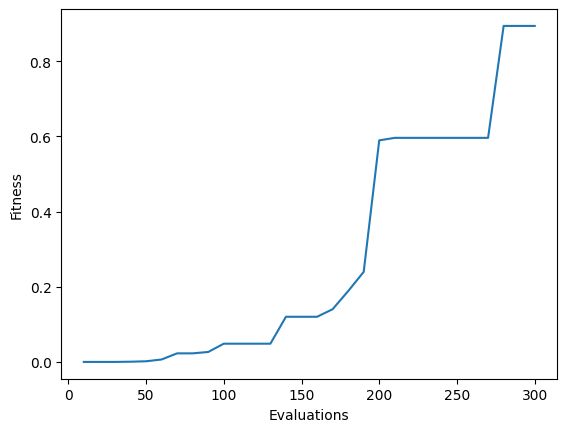

0.8940661577093102

In [105]:
config = {
    "env_name": "Walker-v0",
    "robot": walker,
    "generations": 30, # to change: increase!
    "lambda": 10, # Population size
    "mu": 5, # Parents pop size
    "sigma": 0.1, # mutation std
    "lr": 1, # Learning rate
    "max_steps": 200, # to change to 500
}

a = ES(config)
a.fitness

In [106]:
env = make_env(config["env_name"], robot=config["robot"])
evaluate(a, env, render=False)
env.close()

In [107]:
np.save("Walker.npy", a.genes)

## Pre-trained walker

In [108]:
# load weights

config = {
    "env_name": "Walker-v0",
    "robot": walker,
    "generations": 100,
    "lambda": 10, # Population size
    "mu": 5, # Parents pop size
    "sigma": 0.1, # mutation std
    "lr": 1, # Learning rate
    "max_steps": 500,
}

cfg = get_cfg(config["env_name"], robot=config["robot"]) # Get network dims
cfg = {**config, **cfg} # Merge configs
a = Agent(Network, cfg)
a.genes = np.load("Walker.npy")

In [109]:
env = make_env(cfg["env_name"], robot=cfg["robot"])
a.fitness = evaluate(a, env, render=False)
env.close()
print(a.fitness)

2.413441009115765


In [110]:
import json
def save_solution(a, cfg, name="solution.json"):
    save_cfg = {}
    for i in ["env_name", "robot", "n_in", "h_size", "n_out"]:
        assert i in cfg, f"{i} not in config"
        save_cfg[i] = cfg[i]
    save_cfg["robot"] = cfg["robot"].tolist()
    save_cfg["genes"] = a.genes.tolist()
    save_cfg["fitness"] = float(a.fitness)
    # save
    with open(name, "w") as f:
        json.dump(save_cfg, f)
    return save_cfg

In [111]:
save_solution(a, cfg)

{'env_name': 'Walker-v0',
 'robot': [[3, 3, 3, 3, 3],
  [3, 3, 3, 3, 3],
  [4, 4, 0, 4, 4],
  [4, 4, 0, 4, 4],
  [4, 4, 0, 4, 4]],
 'n_in': 74,
 'h_size': 32,
 'n_out': 22,
 'genes': [-0.36590019380051164,
  0.2620376317832017,
  0.014783796228677565,
  -0.06720550749443432,
  0.11629331341509877,
  -0.3407328783952706,
  -0.2021018613583072,
  -0.496039647739807,
  0.018686895688514817,
  0.11830452248454637,
  -0.025294646567747634,
  0.4629134964706688,
  -0.3002901576714228,
  -0.4360592559818384,
  -0.20665975891865532,
  0.327556719225489,
  -0.03072949763061168,
  0.05147173330452403,
  -0.054914435082783125,
  0.20142349380395969,
  -0.6908346609231402,
  0.3134954359385579,
  -0.10296392349025733,
  -0.17694829462527292,
  -0.06649901278915196,
  -0.25193217336476614,
  0.4779277136619373,
  0.29067661590337585,
  -0.25826552916405676,
  0.12543746865954222,
  0.3007342076275386,
  -0.002524085362313133,
  0.13675464272929172,
  0.20926678991392572,
  0.07654853703657337,
  -0

In [112]:
def load_solution(name="solution.json"):
    with open(name, "r") as f:
        cfg = json.load(f)
    cfg["robot"] = np.array(cfg["robot"])
    cfg["genes"] = np.array(cfg["genes"])
    a = Agent(Network, cfg, genes=cfg["genes"])
    a.fitness = cfg["fitness"]
    return a

In [113]:
a = load_solution(name="solution.json")
cfg = a.config
env = make_env(cfg["env_name"], robot=cfg["robot"])
a.fitness = evaluate(a, env, render=False)
env.close()
print(a.fitness)

2.413441009115765
